# Bornholm BikeNodePlanner–OSM overlap

A compact workflow that loads the original unshifted BikeNodePlanner GeoPackages, matches them to the OSM bike-accessible network, plots matched/unmatched linework, and inspects the unmatched sections.

In [ ]:
# Run once if your environment is missing packages:
# %pip install geopandas osmnx matplotlib pandas shapely pyogrio

## 1. Setup

In [ ]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
import shapely
from IPython.display import display

ox.settings.use_cache = True
ox.settings.log_console = True

working_dir = Path.cwd().resolve()
PROJECT_ROOT = working_dir.parent if working_dir.name == "osm_data_exploration" else working_dir

SAMPLE = "bornholm"
osm_sample = "Bornholm, Denmark"

DATA_DIR = PROJECT_ROOT / f"bikenwloops/data/input/{SAMPLE}/network/processed"

# output folders
OSM_GRAPH_PATH = PROJECT_ROOT / f"osm_data_exploration/outputs/{SAMPLE}/{SAMPLE}_bike_network.graphml"
OUTPUT_DIR = PROJECT_ROOT / f"osm_data_exploration/outputs/{SAMPLE}/overlap_clean"
BOUNDARY_PATH = PROJECT_ROOT /  f"osm_data_exploration/outputs/{SAMPLE}/{SAMPLE}_boundary.geojson"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output folder:", OUTPUT_DIR)

Project root: /Users/ellenebdrup/Documents/GitHub/bike_safety
Output folder: /Users/ellenebdrup/Documents/GitHub/bike_safety/osm_data_exploration/outputs/bornholm/overlap_clean


## 2. Load both networks

The input GeoPackages already contain Bornholm in its real EPSG:25832 position, so no coordinate offset correction is needed.

In [ ]:
study_edges = gpd.read_file(DATA_DIR / "edges_slope.gpkg")
study_nodes = gpd.read_file(DATA_DIR / "nodes.gpkg")

study_edges = study_edges.loc[study_edges.geometry.notna() & ~study_edges.geometry.is_empty].copy()
study_nodes = study_nodes.loc[study_nodes.geometry.notna() & ~study_nodes.geometry.is_empty].copy()

if OSM_GRAPH_PATH.exists():
    G_osm = ox.load_graphml(OSM_GRAPH_PATH)
    print("Loaded existing OSM GraphML.")
else:
    print("Downloading the OSM network...")
    G_osm = ox.graph_from_place(
        osm_sample, 
        network_type="bike", 
        retain_all=True, 
        simplify=True
    )
    G_osm = ox.project_graph(G_osm)
    OSM_GRAPH_PATH.parent.mkdir(parents=True, exist_ok=True)
    ox.save_graphml(G_osm, OSM_GRAPH_PATH)

STUDY_CRS = "EPSG:25832"

osm_nodes, osm_edges = ox.graph_to_gdfs(G_osm)
osm_nodes = osm_nodes.to_crs(STUDY_CRS)
osm_edges = osm_edges.to_crs(STUDY_CRS)

print(f"Study: {len(study_nodes)} nodes, {len(study_edges)} links")
print(f"OSM: {len(osm_nodes):,} nodes, {len(osm_edges):,} directed edges")

Loaded existing OSM GraphML.
Study: 59 nodes, 89 links
OSM: 26,330 nodes, 61,331 directed edges


### If above doesn't work

In [ ]:
sample = "Bornholm, Denmark"
output_dir = Path("outputs/bornholm")
output_dir.mkdir(exist_ok=True)

place_gdf = ox.geocode_to_gdf(sample)
place_poly = place_gdf.geometry.union_all()

# retain_all=True keeps disconnected bike-accessible components.
G = ox.graph_from_polygon(
    place_poly,
    network_type="bike",
    retain_all=True,
    simplify=True,
)

G_proj = ox.project_graph(G)
graph_crs = G_proj.graph["crs"]

print(type(G_proj))
print("Directed:", G_proj.is_directed())
print("CRS:", graph_crs)
print("Nodes:", G_proj.number_of_nodes())
print("Edges:", G_proj.number_of_edges())

ox.io.save_graphml(G_proj, OSM_GRAPH_PATH)
place_gdf.to_file(BOUNDARY_PATH, driver="GeoJSON")

print("Saved graph to:", OSM_GRAPH_PATH)
print("Saved boundary to:", BOUNDARY_PATH)

boundary_proj = place_gdf.to_crs(graph_crs)
nodes, edges = ox.graph_to_gdfs(G_proj)

fig, ax = plt.subplots(figsize=(6, 6))
boundary_proj.plot(ax=ax, facecolor="#fffdf9", edgecolor="#16324f", linewidth=1.1, zorder=1,)
edges.plot(ax=ax, color="#d95f02", linewidth=0.32, alpha=0.82, zorder=2, )
ax.set_title("OSM Bornholm bike-accessible network", fontsize=12)
ax.set_axis_off()
fig.tight_layout()
plt.show()

KeyboardInterrupt: 

## 3. Calculate overlap

A study line is matched where it lies within the selected distance of OSM bike-accessible linework. Dissolving the nearby OSM geometry prevents its two directed copies from being counted twice.

Compare the processed BikeNodePlanner / knudepunkter network with the OpenStreetMap bike-accessible network for Bornholm.

NOTE: we refer to bikewloops as `STUDY`

The notebook measures overlap in both directions:
- Study coverage by OSM: percentage of the unique knudepunkter line length lying within a given distance of an OSM bike-accessible line.
- OSM coverage by the study network: percentage of the unique OSM bike-network length lying within a given distance of a knudepunkter line.
- Node proximity: percentage of knudepunkter nodes within each distance threshold of OSM linework.
Several tolerances are reported because independently digitized lines rarely coincide exactly. A 20 m tolerance is used for the detailed map and link classification; adjust it below if needed.

In [ ]:
# The tolerance in meters for snapping the two networks together. 
# A smaller value may result in fewer overlaps, while a larger value may result in more overlaps.
TOLERANCE_M = 20 

study_network = shapely.union_all(study_edges.geometry.array)

# Keep only OSM edges close enough to influence this comparison.
search_area = study_network.buffer(TOLERANCE_M)
candidate_positions = osm_edges.sindex.query(search_area, predicate="intersects")
osm_edges_near_study = osm_edges.iloc[np.unique(candidate_positions)].copy()
osm_network_near_study = shapely.union_all(osm_edges_near_study.geometry.array)
osm_buffer = osm_network_near_study.buffer(TOLERANCE_M)

matched_geometry = study_network.intersection(osm_buffer)
unmatched_geometry = study_network.difference(osm_buffer)

study_length_m = study_network.length
matched_length_m = matched_geometry.length
unmatched_length_m = unmatched_geometry.length
coverage_pct = 100 * matched_length_m / study_length_m

summary = pd.DataFrame({
    "metric": ["Study length (km)", "Matched length (km)", "Unmatched length (km)", "Coverage (%)"],
    "value": [study_length_m / 1000, matched_length_m / 1000, unmatched_length_m / 1000, coverage_pct],
})
display(summary.round(2))

,metric,value
0,Study length (km),375.73
1,Matched length (km),374.81
2,Unmatched length (km),0.92
3,Coverage (%),99.76


## 4. Plot matched and unmatched portions

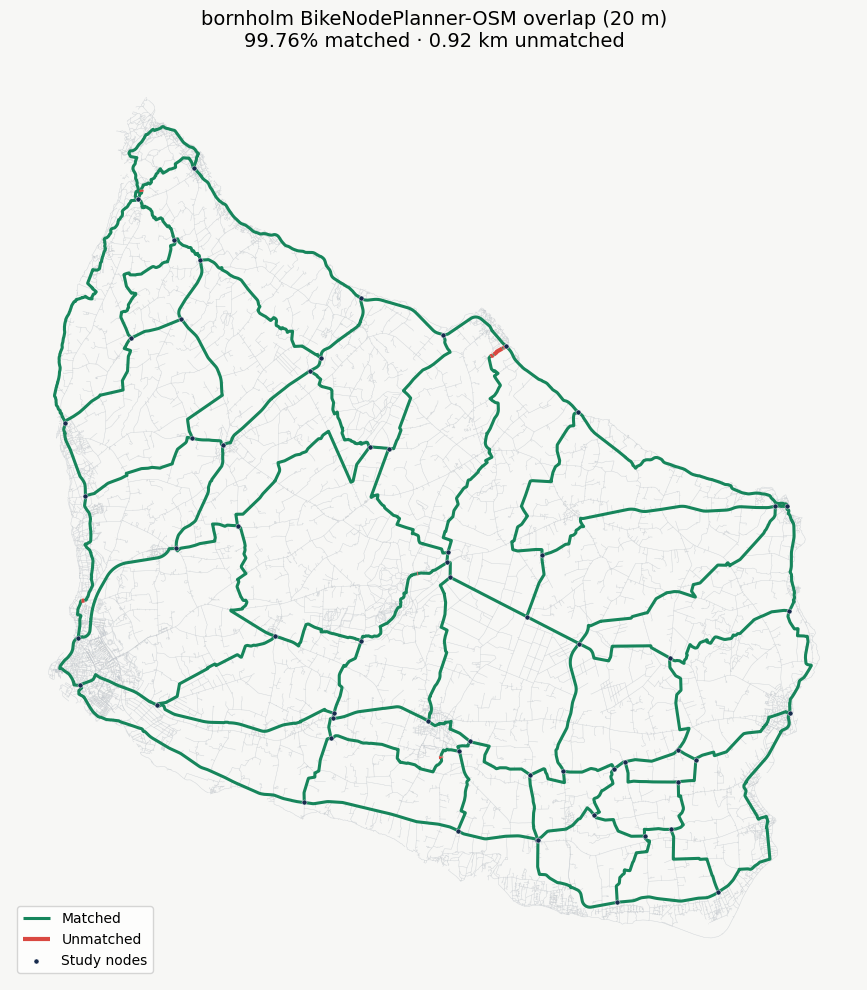

In [10]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor="#f7f7f5")
osm_edges.plot(ax=ax, color="#c8cdd2", linewidth=0.3, alpha=0.5, zorder=1)

gpd.GeoSeries([matched_geometry], crs=STUDY_CRS).plot(
    ax=ax, color="#16855b", linewidth=2.2, label="Matched", zorder=3
)
if not unmatched_geometry.is_empty:
    gpd.GeoSeries([unmatched_geometry], crs=STUDY_CRS).plot(
        ax=ax, color="#d94841", linewidth=3.0, label="Unmatched", zorder=4
    )
study_nodes.plot(
    ax=ax, color="#172b4d", edgecolor="white", linewidth=0.3,
    markersize=13, label="Study nodes", zorder=5
)

ax.set_title(
    f"{SAMPLE} BikeNodePlanner-OSM overlap ({TOLERANCE_M} m)\n"
    f"{coverage_pct:.2f}% matched · {unmatched_length_m / 1000:.2f} km unmatched",
    fontsize=14,
)
ax.legend(loc="lower left")
ax.set_axis_off()
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE}_overlap.png", bbox_inches="tight")
plt.show()

## 5. Inspect unmatched sections

Each red section retains its original study edge ID. Its midpoint is matched to the nearest OSM edge so that names, highway types, access tags, and distance can be inspected.

In [11]:
def line_parts(geometry):
    if geometry is None or geometry.is_empty:
        return
    if geometry.geom_type == "LineString":
        yield geometry
    elif hasattr(geometry, "geoms"):
        for part in geometry.geoms:
            yield from line_parts(part)

records = []
for _, edge in study_edges.iterrows():
    for geometry in line_parts(edge.geometry.difference(osm_buffer)):
        if geometry.length >= 1:  # ignore sub-metre precision fragments
            records.append({
                "edge_id": edge["edge_id"],
                "node_start": edge["node_start"],
                "node_end": edge["node_end"],
                "unmatched_m": geometry.length,
                "geometry": geometry,
            })

unmatched = gpd.GeoDataFrame(records, geometry="geometry", crs=STUDY_CRS)
unmatched.insert(0, "segment_id", np.arange(1, len(unmatched) + 1))

osm_lookup = osm_edges.reset_index()
tag_columns = [
    column for column in ["u", "v", "key", "osmid", "name", "highway", "bicycle", "access", "surface", "geometry"]
    if column in osm_lookup.columns
]
midpoints = gpd.GeoDataFrame(
    unmatched[["segment_id"]],
    geometry=unmatched.geometry.interpolate(0.5, normalized=True),
    crs=STUDY_CRS,
)
nearest = gpd.sjoin_nearest(
    midpoints, osm_lookup[tag_columns], how="left", distance_col="distance_to_osm_m"
)
nearest = (
    nearest.sort_values("distance_to_osm_m")
    .drop_duplicates("segment_id")
    .drop(columns=["geometry", "index_right"], errors="ignore")
)
unmatched = unmatched.merge(nearest, on="segment_id", how="left")

columns = [
    column for column in ["segment_id", "edge_id", "node_start", "node_end", "unmatched_m",
                          "distance_to_osm_m", "osmid", "name", "highway", "bicycle", "access"]
    if column in unmatched.columns
]
display(unmatched[columns].sort_values("unmatched_m", ascending=False).round(2))

,segment_id,edge_id,node_start,node_end,unmatched_m,distance_to_osm_m,osmid,name,highway,access
4,5,65,40,47,410.53,131.55,232690997,NaN,path,NaN
3,4,65,40,47,113.32,74.52,"[232690995, 232690997, 232690999]",NaN,path,NaN
2,3,49,29,38,110.62,25.87,187736132,NaN,path,NaN
5,6,65,40,47,103.22,69.61,215112383,NaN,cycleway,NaN
6,7,88,57,58,83.22,37.35,62324198,NaN,track,NaN
0,1,25,13,17,72.60,45.84,108928691,Haregade,residential,NaN
1,2,46,27,33,24.09,31.93,709572024,Almindingsvej,track,NaN


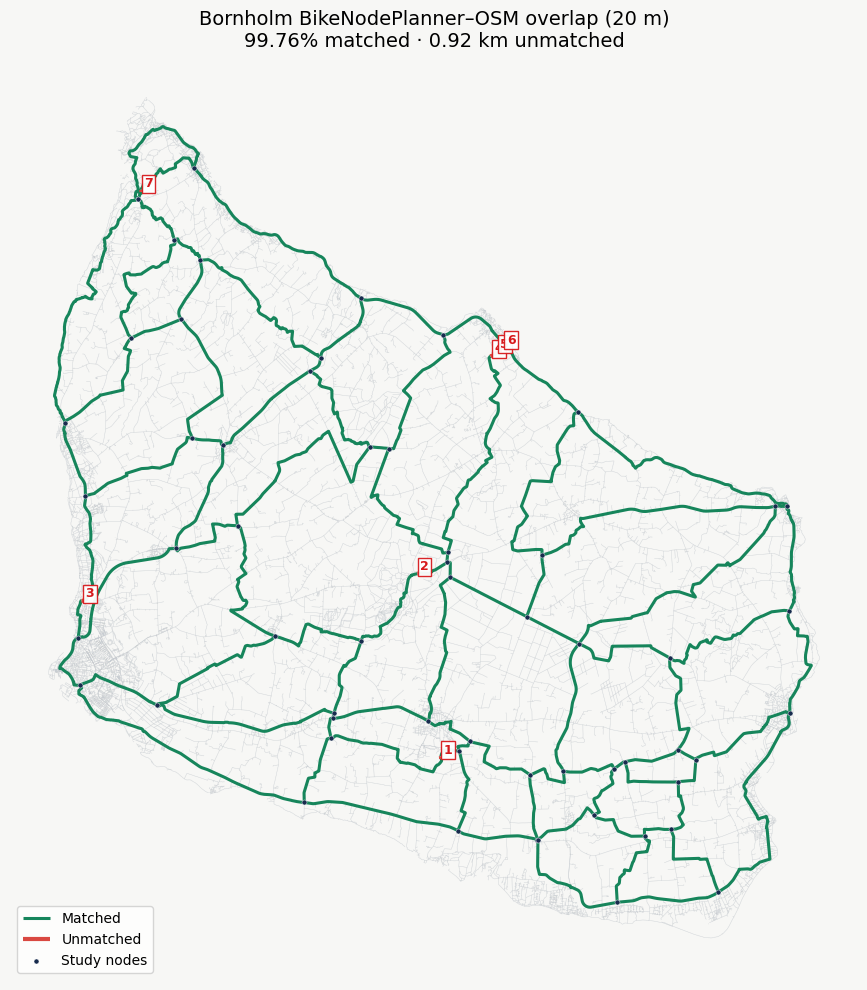

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor="#f7f7f5",)

# OSM network.
osm_edges.plot(
    ax=ax,
    color="#c8cdd2",
    linewidth=0.3,
    alpha=0.5,
    zorder=1,
)

# Matched study geometry.
gpd.GeoSeries(
    [matched_geometry],
    crs=STUDY_CRS,
).plot(
    ax=ax,
    color="#16855b",
    linewidth=2.2,
    label="Matched",
    zorder=3,
)

# Unmatched study segments.
if not unmatched.empty:
    unmatched.plot(
        ax=ax,
        color="#d94841",
        linewidth=3,
        label="Unmatched",
        zorder=4,
    )

    # Add a number beside each unmatched segment.
    for _, segment in unmatched.iterrows():
        label_point = segment.geometry.interpolate(0.5, normalized=True,)

        ax.annotate(
            text=str(segment["segment_id"]),
            xy=(label_point.x, label_point.y,),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            color="#d7191c",
            ha="center",
            va="center",
            bbox={
                "boxstyle": "square,pad=0.2",
                "facecolor": "white",
                "edgecolor": "#d7191c",
                "linewidth": 1,
                "alpha": 0.95,
            },
            zorder=6,
        )

# Study nodes.
study_nodes.plot(
    ax=ax,
    color="#172b4d",
    edgecolor="white",
    linewidth=0.3,
    markersize=13,
    label="Study nodes",
    zorder=5,
)

ax.set_title(
    f"{SAMPLE.title()} BikeNodePlanner–OSM overlap "
    f"({TOLERANCE_M} m)\n"
    f"{coverage_pct:.2f}% matched · "
    f"{unmatched_length_m / 1000:.2f} km unmatched",
    fontsize=14,
)

ax.legend(loc="lower left")
ax.set_axis_off()
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE}_overlap_numbered.png", bbox_inches="tight",)
plt.show()

## 6. Close-ups and export

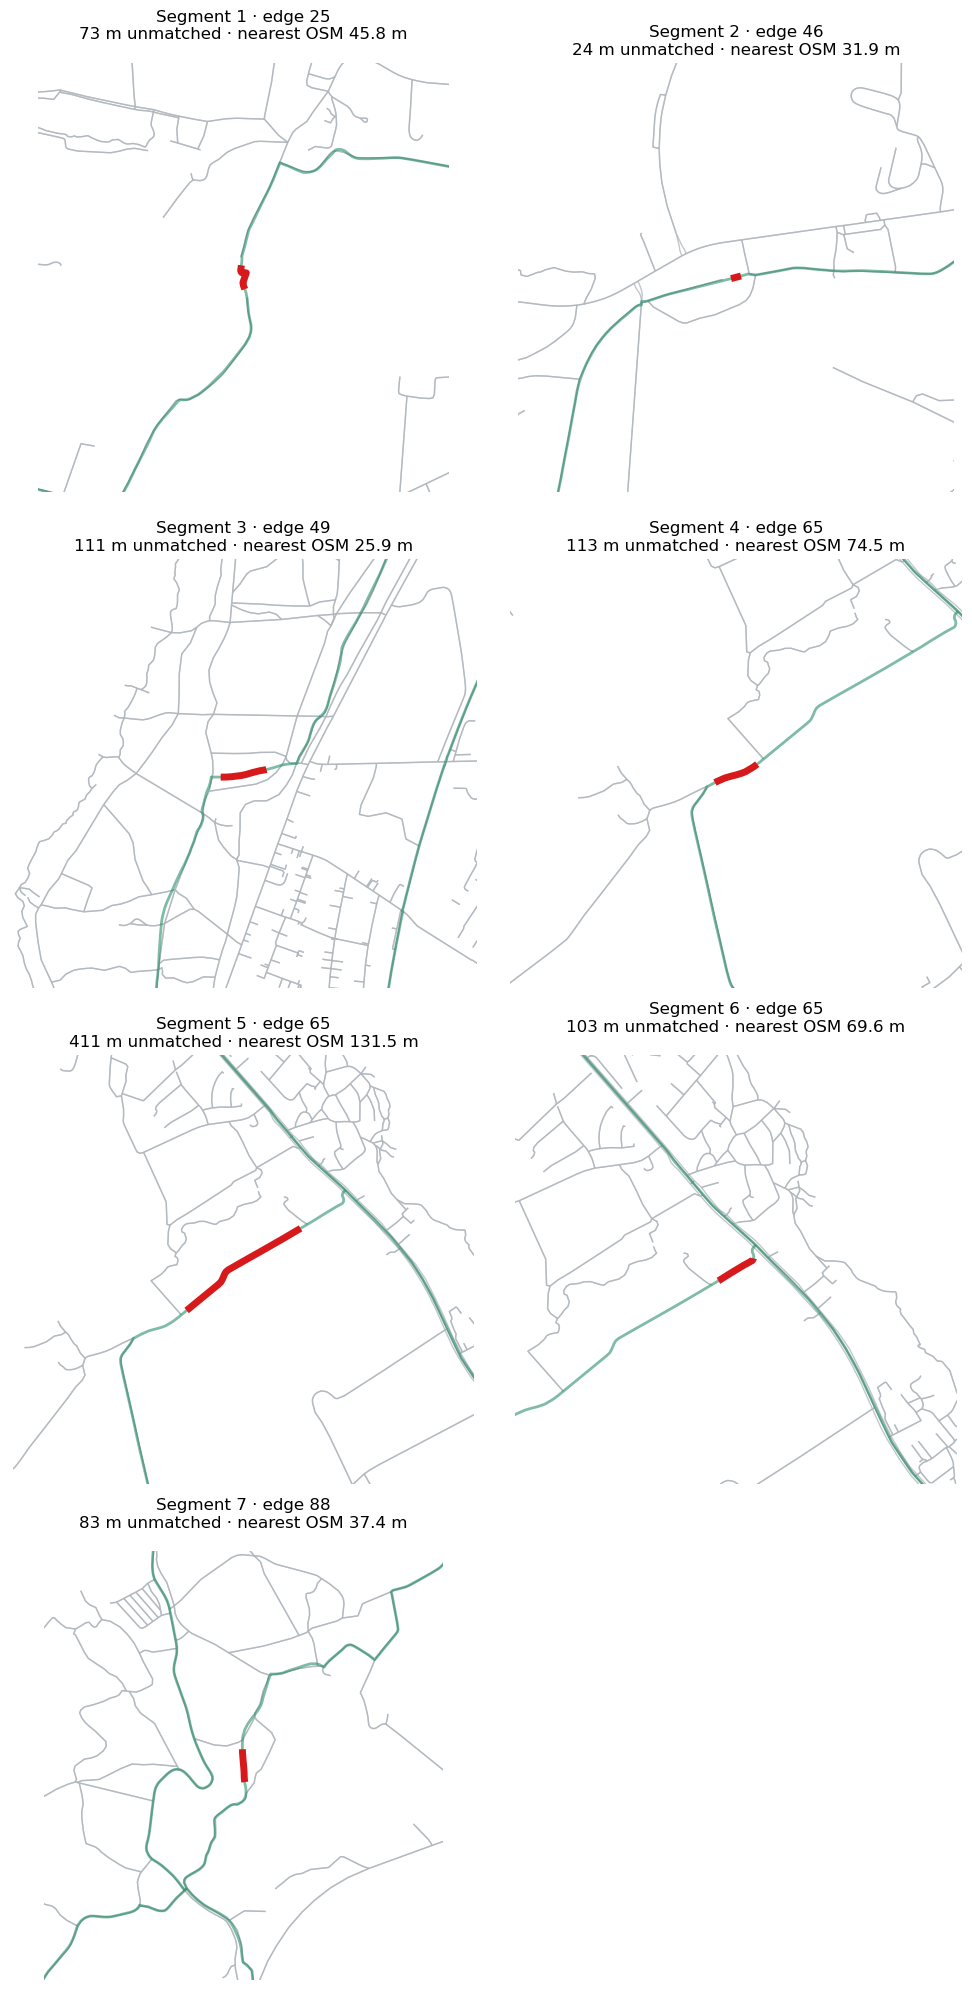

Saved results to: /Users/ellenebdrup/Documents/GitHub/bike_safety/osm_data_exploration/outputs/bornholm/overlap_clean


In [18]:
if len(unmatched):
    ncols = 2
    nrows = int(np.ceil(len(unmatched) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (_, segment) in zip(axes, unmatched.iterrows()):
        minx, miny, maxx, maxy = segment.geometry.buffer(500).bounds
        osm_edges.cx[minx:maxx, miny:maxy].plot(
            ax=ax, color="#aeb5bc", linewidth=1, alpha=0.75
        )
        study_edges.cx[minx:maxx, miny:maxy].plot(
            ax=ax, color="#16855b", linewidth=2, alpha=0.55
        )
        gpd.GeoSeries([segment.geometry], crs=STUDY_CRS).plot(
            ax=ax, color="#d7191c", linewidth=5
        )
        ax.set(xlim=(minx, maxx), ylim=(miny, maxy))
        ax.set_axis_off()
        ax.set_aspect("equal")
        ax.set_title(
            f"Segment {segment['segment_id']} · edge {segment['edge_id']}\n"
            f"{segment['unmatched_m']:.0f} m unmatched · nearest OSM {segment['distance_to_osm_m']:.1f} m"
        )

    for ax in axes[len(unmatched):]:
        ax.set_visible(False)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "unmatched_closeups.png", dpi=200, bbox_inches="tight")
    plt.show()

# Convert list-valued OSM attributes before exporting.
unmatched_export = unmatched.copy()
for column in unmatched_export.columns.drop("geometry"):
    unmatched_export[column] = unmatched_export[column].apply(
        lambda value: "; ".join(map(str, value)) if isinstance(value, (list, tuple, set, np.ndarray)) else value
    )

summary.to_csv(OUTPUT_DIR / "overlap_summary.csv", index=False)
unmatched_export.to_file(
    OUTPUT_DIR / "unmatched_segments.gpkg", layer="segments", driver="GPKG"
)
unmatched_export.drop(columns="geometry").to_csv(
    OUTPUT_DIR / "unmatched_segments.csv", index=False
)
print("Saved results to:", OUTPUT_DIR)